# The Correspondence Principle (Bohr's Formulation)

## Step 0 – Imports and constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# QuTiP is optional for the last section.
try:
  from qutip import Qobj
  _HAS_QUTIP = True
except Exception as err:
  _HAS_QUTIP = False
  print("QuTiP not available in this environment. Step 6 will be skipped.")
  print("Error:", err)

# --- Physical constants (SI) ---
h = 6.62607015e-34         # J s
hbar = h/(2*np.pi)         # J s
e = 1.602176634e-19        # C 
m = 9.1093837015e-31       # kg (electron mass)
eps0 = 8.8541878128e-12    # F/m
ke = 1/(4*np.pi*eps0)      # Coulomb constant
c = 299792458              # m/s
alpha = e**2/(4*np.pi*eps0*hbar*c)  # finite-structure constant

def ev_to_joule(E_eV):
  return E_ev * e

def joule_to_ev(E_J):
  return E_J / e


/home/jp/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Step 1 – Warm-up: de Broglie wavelength and the "classical limit"

**Compute** $\lambda$ = h/(mv)$ for:

- baseball: $m=0.15$ kg, $v=20$ m/s

- electron: $v=5.9\times 10^6$ m/s

**Why baseball does not diffract measurably**:

- Its de Broglie wavelength is **astronomically small** compared with any experimental aperture or grating spacing.

- Any interference fringes would have spacing far below atomic scales, so the wave nature is effectively unobservable $\rightarrow$ classical trajectory description works.


In [2]:
def de_broglie_lambda(mass, speed):
  return h/(mass*speed)
lam_baseball = de_broglie_lambda(0.15, 20.0)
lam_electron = de_broglie_lambda(m, 5.9e6)

print(f"Baseball lambda = {lam_baseball:.2e} m")
print(f"Electron lambda = {lam_electron:.2e} m = {lam_electron*1e9:.2f} nm")


Baseball lambda = 2.21e-34 m
Electron lambda = 1.23e-10 m = 0.12 nm


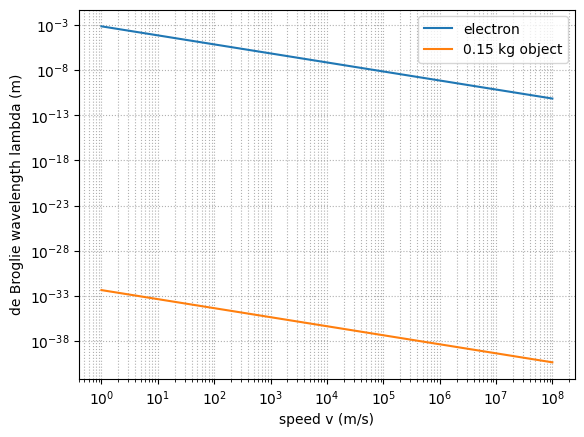

In [3]:
#visualize lambda(v) for an electron vs a macroscopic mass
v = np.logspace(0, 8, 400)       # 1 m/s to 1e8 m/s
lam_e = h/(m*v)
lam_macro = h/(0.15*v)

plt.figure()
plt.loglog(v, lam_e, label="electron")
plt.loglog(v, lam_macro, label="0.15 kg object")
plt.xlabel("speed v (m/s)")
plt.ylabel("de Broglie wavelength lambda (m)")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()

## Step 2 – Bohr energies and transition frequencies

For a hydrogen-like atom,

$$E_n = -\frac{m}{2\hbar^2}\Big(\frac{Ze^2}{4\pi\varepsilon_0}\Big)^2\frac{1}{n^2}.$$

A transtition $(n+k)\rightarrow n$ emits a photon with:

$$\nu_{n,k} = \frac{E_{n+k}-E_n}{h}.$$

**Note (trend)**: for fixed $k,\nu_{n,k}$ decreases as $n$ increases (level spacing shrinks like $1/n^3$ for large $n$).


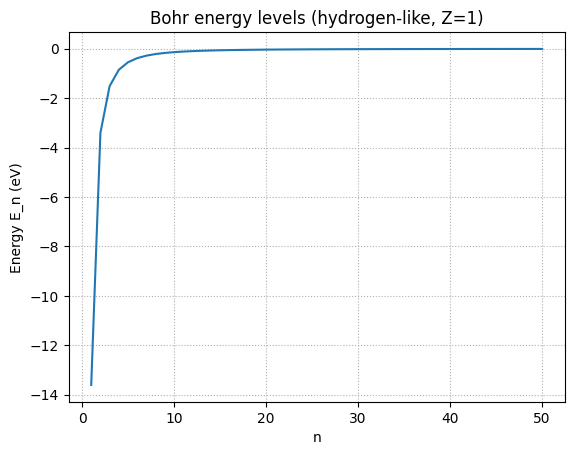

In [4]:
def E_bohr(n, Z=1):
  return -m/(2*hbar**2)*(Z*e**2/(4*np.pi*eps0))**2*(1/(n**2))

def nu_transition(n, k, Z=1):
  return (E_bohr(n+k)-E_bohr(n))/h

# Energy levels
n = np.arange(1,51)
E = E_bohr(n, Z=1)

plt.figure()
plt.plot(n, joule_to_ev(E))
plt.xlabel("n")
plt.ylabel("Energy E_n (eV)")
plt.title("Bohr energy levels (hydrogen-like, Z=1)")
plt.grid(True, ls=":")
plt.show()


## Step 3 – Large-$n$ approximation

In the correspondence limit $n\rightarrow\infty$ with $k=\Delta n$ fixed (so $k/n<<1$),

$$\frac{1}{(n+k)^2}=\frac{1}{n^2}\Big(1+\frac{k}{n}\Big)^{-2}\approx \frac{1}{n^2}\Big(1- \frac{2k}{n} + \frac{3k^2}{n^2} - \dots\Big).$$

Therefore, 

$$\frac{1}{n^2}-\frac{1}{(n+k)^2}\approx\frac{2k}{n^3}-\frac{3k^2}{n^4}+\mathcal{O}\Big(\frac{k^3}{n^5}\Big),$$

and the leading-order result is

$$\nu_{n,k}\approx\nu_{n,k}^{approx}=\frac{m}{4\pi\hbar^3}\Big(\frac{Ze^2}{4\pi\varepsilon_0}\Big)\frac{2k}{n^3}.$$

**Note**: $\nu_{\text{exact}}/\nu_{\text{approx}}\rightarrow\infty$ **for fixed** $k$. The relative error scales as $\mathcal{O}(k/n)$ (e.g., from the next term $~\frac{3}{2}k/n$), so convergence is faster when $k/n$ is smaller.


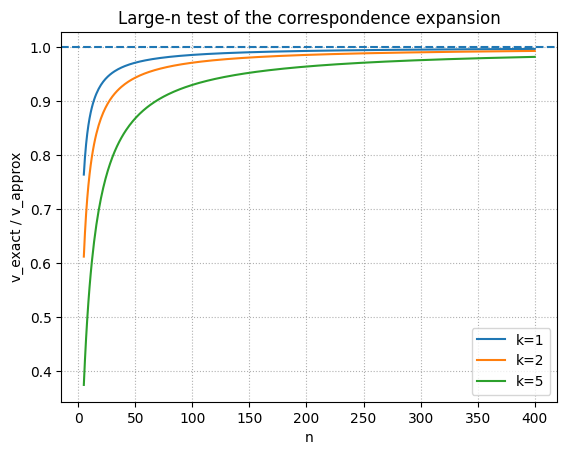

In [5]:
def nu_approx(n, k, Z=1):
  n = np.asarray(n, dtype=float)
  C = m/(4*np.pi*hbar**3) * (Z*e**2/(4*np.pi*eps0))**2
  return C * (2*k)/(n**3)

n = np.arange(5, 401)
ks = [1, 2, 5]
 
plt.figure()
for k in ks:
  ratio = nu_transition(n, k)/nu_approx(n, k)
  plt.plot(n, ratio, label=f"k={k}")
plt.axhline(1.0, ls="--")
plt.xlabel("n")
plt.ylabel("v_exact / v_approx")
plt.title("Large-n test of the correspondence expansion")
plt.legend()
plt.grid(True, ls=":")
plt.show()


In [6]:
# Quantify "close to 1": find the smallest n where |ratio-1|<1% for all larger 
# n (for each k)
def n_for_tolerance(k, tol=0.01, nmin=5, nmax=2000):
  n = np.arange(nmin, nmax+1)
  ratio = nu_transition(n, k)/nu_approx(n, k)
  ok = np.abs(ratio - 1) < tol
  # find first index from  which all remaining are ok
  for i in range(len(n)):
    if ok[i:].all():
      return int(n[i])
  return None

for k in [1,2,5,10]:
  n_star = n_for_tolerance(k, tol=0.01, nmax=5000)
  print(f"k={k:2d}: |v_exact/v_approx - 1| < 1% for all n >= {n_star}")


k= 1: |v_exact/v_approx - 1| < 1% for all n >= 149
k= 2: |v_exact/v_approx - 1| < 1% for all n >= 298
k= 5: |v_exact/v_approx - 1| < 1% for all n >= 744
k=10: |v_exact/v_approx - 1| < 1% for all n >= 1487


## Step 4 – Classical orbital frequency and the harmonic match

Bohr model:

$$r_n = a_0\frac{n^2}{Z}, a_0 = \frac{4\pi\varepsilon_0 \hbar^2}{me^2}$$

- $r_n$: radius of the $n$-th Bohr orbit (hydrogen-like ion).

- $a_0$: Bohr radius (sets the atomic length scale).

- $Z$: nuclear charge (atomic number for hydrogen-like ions).

$$v_n = \frac{Ze^2}{2\pi\varepsilon_0 \hbar}\frac{1}{n} = \frac{Z\alpha c}{n}$$

- $v_n$: electron **speed** in the $n$-th orbit (decreases as $1/n$).

- $\alpha$: fine-structure constant, $c$: speed of light.

$$\nu_{\text{cl}}(n) = \frac{v_n}{2\pi r_n}.$$

- $\nu_{\text{cl}}(n)$: **classical orbital (revolution) frequency** (turns per second).
(*Here $v_n$ is a speed, while $\nu_{\text{cl}}$ is a frequency.*)

**Interpretation**: The correspondence principle predicts

$$\nu_{n,k}\approx k\nu_{\text{cl}}(n)$$

so, for large $n$ (with $k=\Delta n$ fixed), quantum transition frequencies match the $k$-**th armonic** of the classical orbital motion.


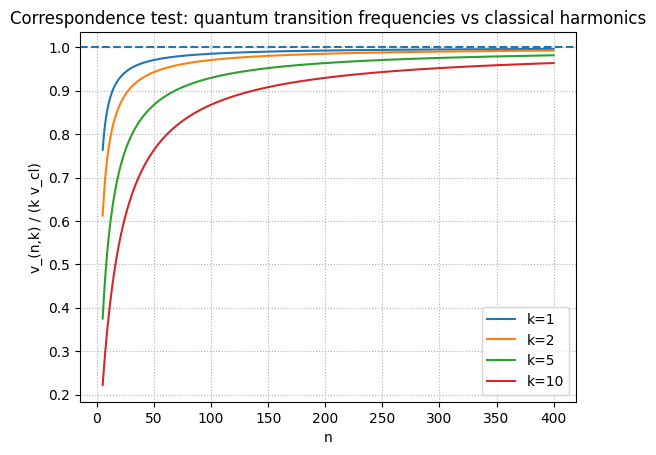

In [7]:
a0 = 4*np.pi*eps0*hbar**2/(m*e**2)

def r_bohr(n, Z=1):
  n = np.asarray(n, dtype=float)
  return a0 * n**2 / Z

def v_bohr(n, Z=1):
  n = np.asarray(n, dtype=float)
  return (Z*e**2/(4*np.pi*eps0*hbar)) * (1/n)

def nu_classical(n, Z=1):
  return v_bohr(n, Z)/(2*np.pi*r_bohr(n, Z))

n = np.arange(5, 401)

plt.figure()
for k in [1, 2, 5, 10]:
  ratio = nu_transition(n, k)/(k*nu_classical(n))
  plt.plot(n, ratio, label=f"k={k}")
plt.axhline(1.0, ls="--")
plt.xlabel("n")
plt.ylabel("v_(n,k) / (k v_cl)")
plt.title("Correspondence test: quantum transition frequencies vs classical "
"harmonics")
plt.legend()
plt.grid(True, ls=":")
plt.show()


**Explanation (2-3 lines)**



## Step 5 – "Selection rule" as an intensity trend (toy model + dipole context)

From Step 4 (harmonic matching), we have the frequency correspondence

$$\nu_{n,k}=k\nu_{\text{cl}}(n),$$

so the transition $\Delta n = k$ lines up with the $k$**-th harmonic** of the classical orbital motion.

### Why talk about "intensity" at all?

Matching the **frequency** does not automatically tell us which spectral lines are **strongest**.
To get a minimal (and model-independent) trend, we use the classical idea:

  Periodic motion contains harmonics, but **higher harmonics are typically weaker** than the fundamental.
  
### A toy intensity model (used in this lab)

We encode that trend with a simple phenomenological scaling:

$$I_k \propto \frac{1}{k^p} \,\,\ (p>0),$$

where $I_k$ represents a **relative line intensity** associated with $\Delta n = k.$

- $p$ controls how fast higher$-k$ transitions are supressed.

- This is **not** a fundamental law; it is a compact way to capture the "higher harmonics are weaker" trend.

### What the *dipole formalism* does in full quantum mechanics (context)

In modern QM, line intensities and strict selection rules come from the **light-matter interaction**.

At lowest order (electric-dipole / E1 approximation), the interaction is governed by the **dipole operator**

$$\mathbf{d} = -e\mathbf{r},$$

and the transition strength depends on a **matrix element** between initial and final states:

$$\text{(transition} \,\ \text{strength)} \propto |\langle f|\mathbf{d}|i\rangle|^2.$$

### What does $|\langle f|\mathbf{d}|i\rangle|$ mean?

- $|i\rangle$ is the **initial** quantum state and $|f\rangle$ is the **final** quantum state.

- $|\langle f|\mathbf{d}|i\rangle|$ is the **transition amplitude** for E1 emission/absorption: it measures how strongly the operator $\mathbf{d}$ can connect $|i\rangle$ to $|f\rangle$.

- If $|\langle f|\mathbf{d}|i\rangle|=0$, the transition is **E1-forbidden** (it cannot occur via electric-dipole radiation).

- If is nonzero, the line is allowed, and its intensity scales with $|\langle f|\mathbf{d}|i\rangle|$ (larger values \Rightarrow stronger line).

**Key points:**

- This formalism provides both:

  1. **selection rules** (when the matrix element must be zero by symmetry), and 
  
  2. **relative intensities** (how large the matrix element is when allowed).
  
- For hydrogen-like atoms in E1, the strongest selection rules are typically:

$$\Delta l = \pm 1, \,\,\ \Delta m= 0, \pm 1,$$

while $\Delta n$ is **not** strictly restricted by E1 alone.

- Nevertheless, in the **large**$-n$ regime, matrix elements often favor **nearby** levels, so the qualitative trend "$\Delta n=1$ is often strongest" can still emerge–this is what our toy model mimics *without* requiring the full E1 derivation.

**Why we do *not* use the full dipole formalism here:**

This lab focuses on the correspondence principle (frequency/harmonic structure). The toy model gives  a clean, intuitive bridge from "harmonics" $\rightarrow$ "dominant lines" without introducing the full angular-momentum selection-rule machinery.



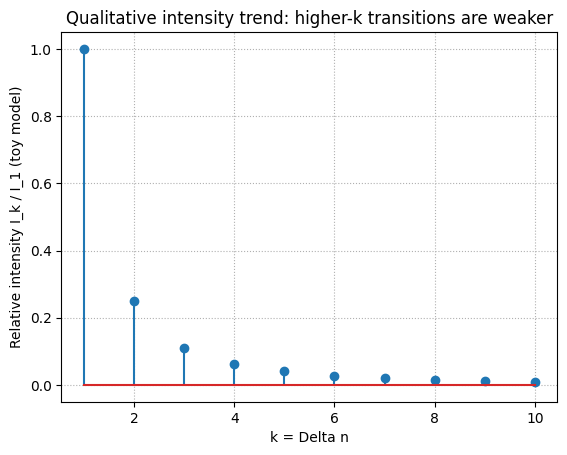

In [21]:
k = np.arange(1, 11)
p = 2
I = 1/(k**p)
I_norm = I/I[0]

plt.figure()
plt.stem(k, I_norm)
plt.xlabel("k = Delta n")
plt.ylabel("Relative intensity I_k / I_1 (toy model)")
plt.title("Qualitative intensity trend: higher-k transitions are weaker")
plt.grid(True, ls=":")
plt.show()


**Interpretation of the intensity plot (2-3 lines)**

## Step 6 – QuTiP "spectral operator" toy model

We build an **N-level Bohr Hamiltonian** and a **coupling operator** $A$ in the $|n\rangle$ basis with weights that decay with $\Delta n$. This visualizes "adjacent transitions dominate" as a property of coupling strength, without introducing aaditional theory.

### What is this step doing?

In this step we build an **N-level Bohr Hamiltonian** and a **toy coupling operator** $A$ in the $\{|n\rangle\}$ basis.

- $H$ is diagonal in $\{|n\rangle\}$ and contains the Bohr energy levels (it defines the level structure).

- $A$ is a **phenomenological coupling operator**: we choose its matrix elements to decay with the jump size.

$$k = \Delta n,$$

so that nearby levels couple more strongly:

$$A_{n,n+k}\propto e^{-k/k_0}.$$

**Important**: $A$ is **not** the physical dipole operator. Its only purpose is to **visualize** the idea that "adjacent transitions dominate" when the coupling between levels decrease with $\Delta n$.

### What we test

We fix a large $n_0$ and plot the relative coupling strength

$$\frac{|\langle n_0|A|n_0+k\rangle|^2}{|\langle n_0|A|n_0+1\rangle|^2}$$

as a function of $k = \Delta n$.

**Expected trend**: the ratio drops rapidly with $k$ (approximately like $e^{-2k/k_0}$ after squaring), showing that $\Delta n =1$ transitions are typically the strongest in this toy picture.


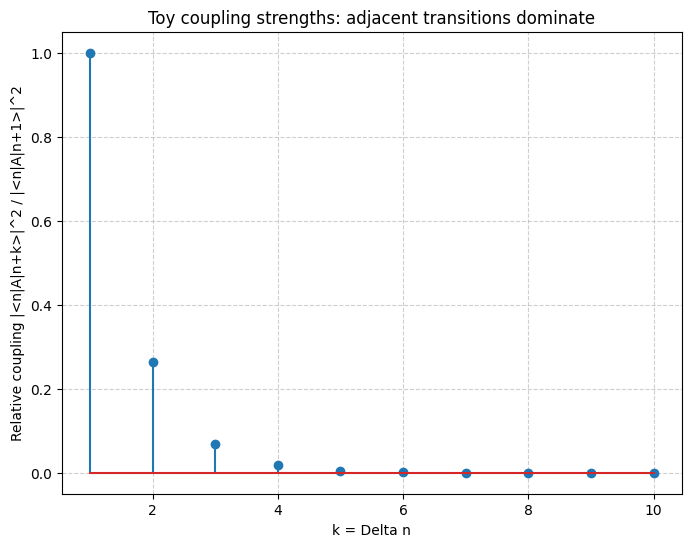

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from qutip import Qobj, basis

N = 120
Z = 1
k0 = 1.5

n_levels = np.arange(1, N)
E_levels = E_bohr(n_levels, Z)
H = qt.Qobj(np.diag(E_levels))

A_mat = np.zeros((N,N), dtype=complex)
for i in range(N):
  for j in range(N):
    k = abs((j+1)-(i+1))
    if k!=0:
      A_mat[i,j] = np.exp(-k/k0)
A = qt.Qobj(A_mat)

n0 = 80
i0 = n0 - 1
ks=[1,2,3,4,5,6,7,8,9,10]
strength = {}
ket_n0 = qt.basis(N, i0)
for k in ks:
  ket_n0k = qt.basis(N, i0+k)
  amp_qobj = (ket_n0.dag() * A * ket_n0k)
  if isinstance(amp_qobj, qt.Qobj):
    val = amp_qobj[0, 0]
  else:
    val = amp_qobj
  strength[k] = np.abs(val)**2

strength_norm = {k: strength[k] / strength[1] for k in ks}

k_values = list(strength_norm.keys())
values = list(strength_norm.values())
plt.figure(figsize=(8, 6))
# Se elimina 'use_line_collection' para compatibilidad con versiones modernas
plt.stem(k_values, values)
plt.xlabel("k = Delta n")
plt.ylabel(r"Relative coupling |<n|A|n+k>|^2 / |<n|A|n+1>|^2")
plt.title("Toy coupling strengths: adjacent transitions dominate")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [30]:
ket_n0k

Quantum object: dims=[[120], [1]], shape=(120, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]